<a href="https://colab.research.google.com/github/mrivassnj-svg/HCC_ITAI_1371_SPR26/blob/main/Module_09_Lab_Ensemble_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Module 09 Lab
# Ensemble Methods
**Objective:**

 To learn how to use **ensemble methods**, which combine the predictions of several individual models to produce a final prediction that is more accurate and robust than any of the individual models alone.

 **In this lab, you will train and compare a single Decision Tree against a powerful ensemble method, the Random Forest.**

# Part 1: The Wisdom of the Crowd
**Concept:**

The core idea behind ensemble methods is the "wisdom of the crowd." If you ask one person a difficult question, they might be wrong. But if you ask a large, diverse group of people the same question and average their answers, the result is often surprisingly accurate.Ensemble methods apply this to machine learning. Instead of relying on a single model, we build a "committee" of models and have them vote on the final prediction.Two popular ensemble techniques:*   
- **Bagging (Bootstrap Aggregating):** \
Trains multiple models (e.g., Decision Trees) on different random subsets of the training data. The **Random Forest** is the most famous example.   
- **Boosting:** \
Trains models sequentially, where each new model focuses on correcting the errors made by the previous one. Examples include Gradient Boosting and AdaBoost.

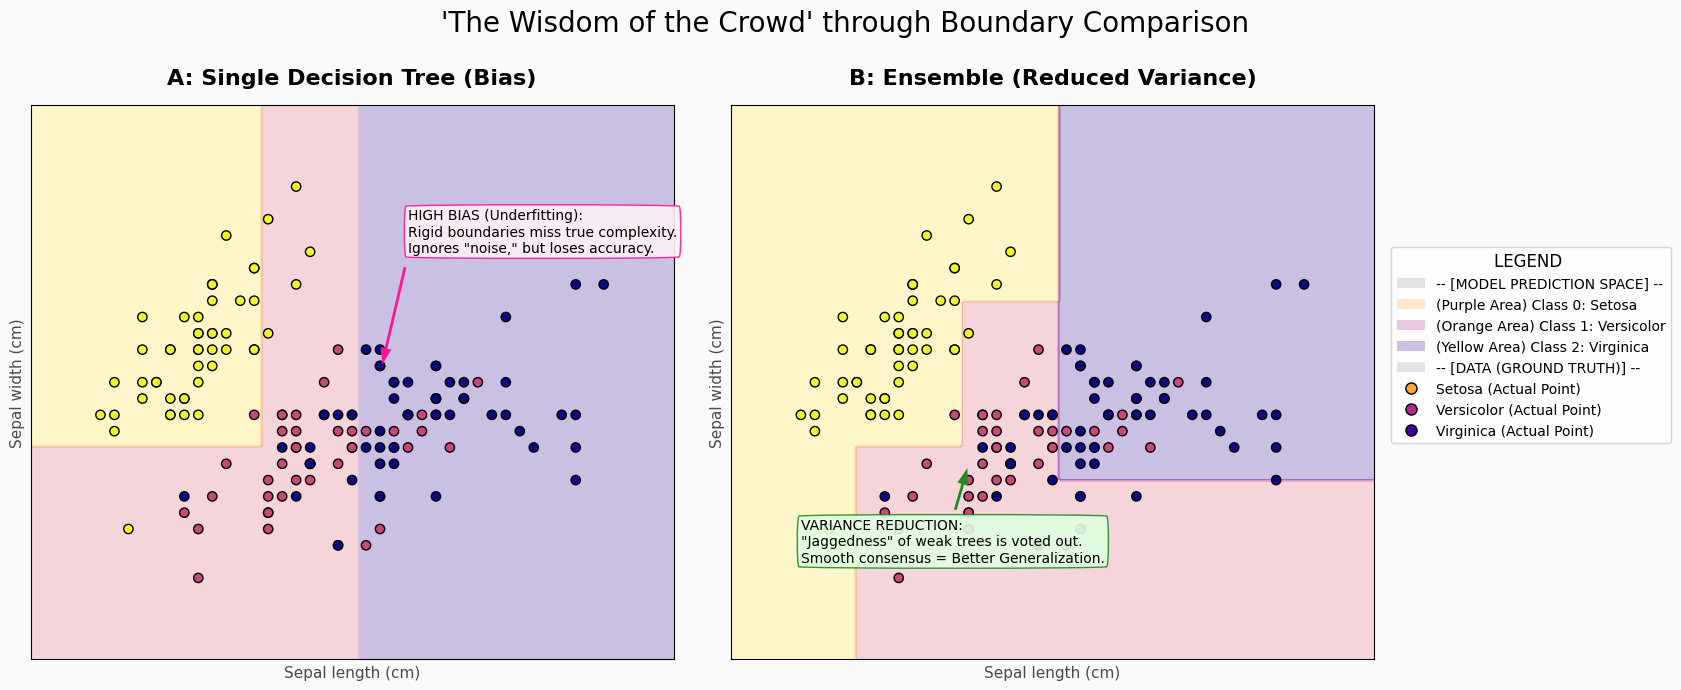

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import train_test_split
from matplotlib.patches import Patch

# --- 1. DATA PREPARATION ---
# Use 2 features (Sepal length/width) to make mistakes visible in 2D.
iris = load_iris()
X = iris.data[:, :2]
y = iris.target

# Target names for labeling
target_names = iris.target_names # ['setosa', 'versicolor', 'virginica']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# --- 2. DIVERSITY CREATION ---
# Create diverse "experts" by varying max_depth.
tree1 = DecisionTreeClassifier(max_depth=2, random_state=1)
tree2 = DecisionTreeClassifier(max_depth=3, random_state=2)
tree3 = DecisionTreeClassifier(max_depth=4, random_state=3)

# Consensus mechanism (Hard voting: majority rule)
voting = VotingClassifier(
    estimators=[('t1', tree1), ('t2', tree2), ('t3', tree3)],
    voting='hard'
)

# Fit all models
for model in [tree1, tree2, tree3, voting]:
    model.fit(X_train, y_train)

# --- 3. CODED VISUAL LEGEND & ANNOTATION LOGIC ---

def plot_and_annotate(model, title, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # cmap choices (must match)
    cmap_bg = plt.cm.plasma_r
    cmap_pts = plt.cm.plasma_r

    # Draw Decision Territory (Background)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=cmap_bg) # Translucent background

    # Draw Actual Data Points (Foreground)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor='black', s=45, cmap=cmap_pts)

    # Axis & Title formatting
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Sepal length (cm)', fontsize=11, alpha=0.7)
    ax.set_ylabel('Sepal width (cm)', fontsize=11, alpha=0.7)
    ax.grid(True, linestyle='--', alpha=0.15)
    ax.set_xticks([]); ax.set_yticks([]) # Simplify for concept

# Initialize Figure (wider for legend placement)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7), facecolor='#FAFAFA')

# PLOT 1: Single Tree
plot_and_annotate(tree1, "\nA: Single Decision Tree (Bias)", ax1)
# Key Annotation pointing to rigid boundary
ax1.annotate('HIGH BIAS (Underfitting):\nRigid boundaries miss true complexity.\nIgnores "noise," but loses accuracy.',
             xy=(6.3, 3.25), xytext=(6.5, 4.0), fontsize=10,
             arrowprops=dict(facecolor='#FF1493', edgecolor='none', shrink=0.08, width=2, headwidth=8),
             bbox=dict(boxstyle="round4", fc="#FFF0F5", ec="#FF1493", alpha=0.9))

# PLOT 2: The Consensus (Ensemble)
plot_and_annotate(voting, "\nB: Ensemble (Reduced Variance)", ax2)
# Key Annotation pointing to smoothed correction
ax2.annotate('VARIANCE REDUCTION:\n"Jaggedness" of weak trees is voted out.\nSmooth consensus = Better Generalization.',
             xy=(5.5, 2.7), xytext=(4.3, 2.1), fontsize=10,
             arrowprops=dict(facecolor='#228B22', edgecolor='none', shrink=0.08, width=2, headwidth=8),
             bbox=dict(boxstyle="round4", fc="#E0FFE0", ec="#228B22", alpha=0.9))

# --- 4. CREATE CONTEXTUAL LEGEND BOX ---
# Programmatically retrieve colors and assign meanings

cmap_instance = plt.cm.plasma_r
# Get colors for classes 0, 1, 2 at typical levels (plasma is cyclic-ish)
color_0 = cmap_instance(0.2)
color_1 = cmap_instance(0.6)
color_2 = cmap_instance(0.9)

# Define Legend Patches for BG and Markers for Points
legend_elements = [
    Patch(facecolor='black', edgecolor='none', alpha=0.1, label='-- [MODEL PREDICTION SPACE] --'),
    Patch(facecolor=color_0, alpha=0.25, edgecolor='none', label='(Purple Area) Class 0: Setosa'),
    Patch(facecolor=color_1, alpha=0.25, edgecolor='none', label='(Orange Area) Class 1: Versicolor'),
    Patch(facecolor=color_2, alpha=0.25, edgecolor='none', label='(Yellow Area) Class 2: Virginica'),
    Patch(facecolor='black', edgecolor='none', alpha=0.1, label='-- [DATA (GROUND TRUTH)] --'),
    plt.Line2D([0], [0], marker='o', color='none', markerfacecolor=color_0, markersize=8, markeredgecolor='k', label='Setosa (Actual Point)'),
    plt.Line2D([0], [0], marker='o', color='none', markerfacecolor=color_1, markersize=8, markeredgecolor='k', label='Versicolor (Actual Point)'),
    plt.Line2D([0], [0], marker='o', color='none', markerfacecolor=color_2, markersize=8, markeredgecolor='k', label='Virginica (Actual Point)')
]

# Add the Legend to the Figure (right side)
fig.legend(handles=legend_elements, loc='center right', title='LEGEND ',
           title_fontsize=12, fontsize=10, frameon=True, bbox_to_anchor=(0.99, 0.5))

plt.tight_layout(rect=[0, 0, 0.82, 0.95]) # Make space for legend
fig.suptitle("'The Wisdom of the Crowd' through Boundary Comparison", fontsize=20, y=0.98)
plt.show()

# Part 2: Setup
We will use the Iris dataset to classify flower species.

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load and prepare data
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

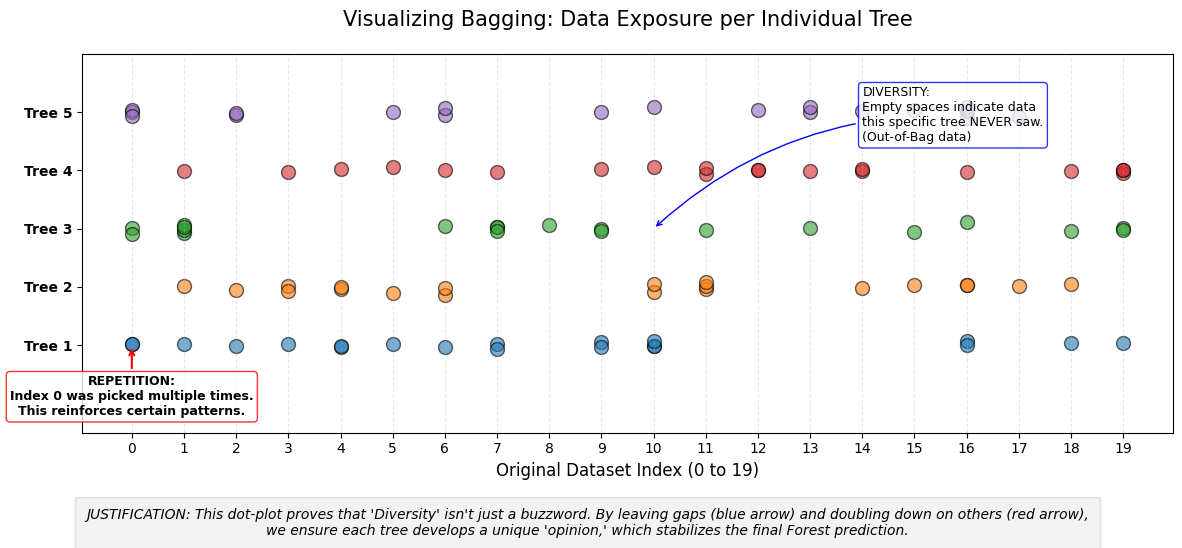

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETUP ---
n_samples = 20   # Small number to make individual "data identities" visible
n_trees = 5

# Generate bootstrap samples
samples = [
    np.random.choice(range(n_samples), size=n_samples, replace=True)
    for _ in range(n_trees)
]

plt.figure(figsize=(12, 5), facecolor='white')

# --- 2. THE PLOT ---
for i, sample in enumerate(samples):
    # We add a 'jitter' (np.random.normal) so overlapping points
    # look like a "cloud," visually representing frequency.
    jitter = np.random.normal(0, 0.05, size=len(sample))
    plt.scatter(sample, np.array([i]*len(sample)) + jitter,
                alpha=0.6, s=100, edgecolors='k', label=f"Tree {i+1} Training Set")

# --- 3. JUSTIFICATION & ANNOTATIONS ---
# Identify a specific repeated point for the annotation
val, counts = np.unique(samples[0], return_counts=True)
repeat_val = val[counts > 1][0] # Find a point that was picked > 1 time

plt.annotate(f"REPETITION:\nIndex {repeat_val} was picked multiple times.\nThis reinforces certain patterns.",
             xy=(repeat_val, 0), xytext=(repeat_val, -1.2),
             ha='center', fontsize=9, fontweight='bold',
             arrowprops=dict(arrowstyle="->", color='red', lw=1.5),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8))

plt.annotate("DIVERSITY:\nEmpty spaces indicate data\nthis specific tree NEVER saw.\n(Out-of-Bag data)",
             xy=(10, 2), xytext=(14, 3.5),
             ha='left', fontsize=9,
             arrowprops=dict(arrowstyle="->", color='blue', connectionstyle="arc3,rad=.2"),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="blue", alpha=0.8))

# --- 4. FORMATTING ---
plt.yticks(range(n_trees), [f"Tree {i+1}" for i in range(n_trees)], fontweight='bold')
plt.xticks(range(n_samples))
plt.xlabel("Original Dataset Index (0 to 19)", fontsize=12)
plt.title("Visualizing Bagging: Data Exposure per Individual Tree", fontsize=15, pad=20)
plt.ylim(-1.5, n_trees)
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Contextual Legend justifying the method
plt.figtext(0.5, -0.08,
            "JUSTIFICATION: This dot-plot proves that 'Diversity' isn't just a buzzword. "
            "By leaving gaps (blue arrow) and doubling down on others (red arrow),\n"
            "we ensure each tree develops a unique 'opinion,' which stabilizes the final Forest prediction.",
            ha="center", fontsize=10, style='italic', bbox={"facecolor":"grey", "alpha":0.1, "pad":8})

plt.tight_layout()
plt.show()

# Part 3:
A Single Decision TreeA single Decision Tree is prone to overfitting. It can create very specific rules that match the training data perfectly but don't generalize well.

**Your Task:**

Train a single `DecisionTreeClassifier` and evaluate its accuracy.

/tmp/ipykernel_5531/1742217056.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 0.82, 0.95])


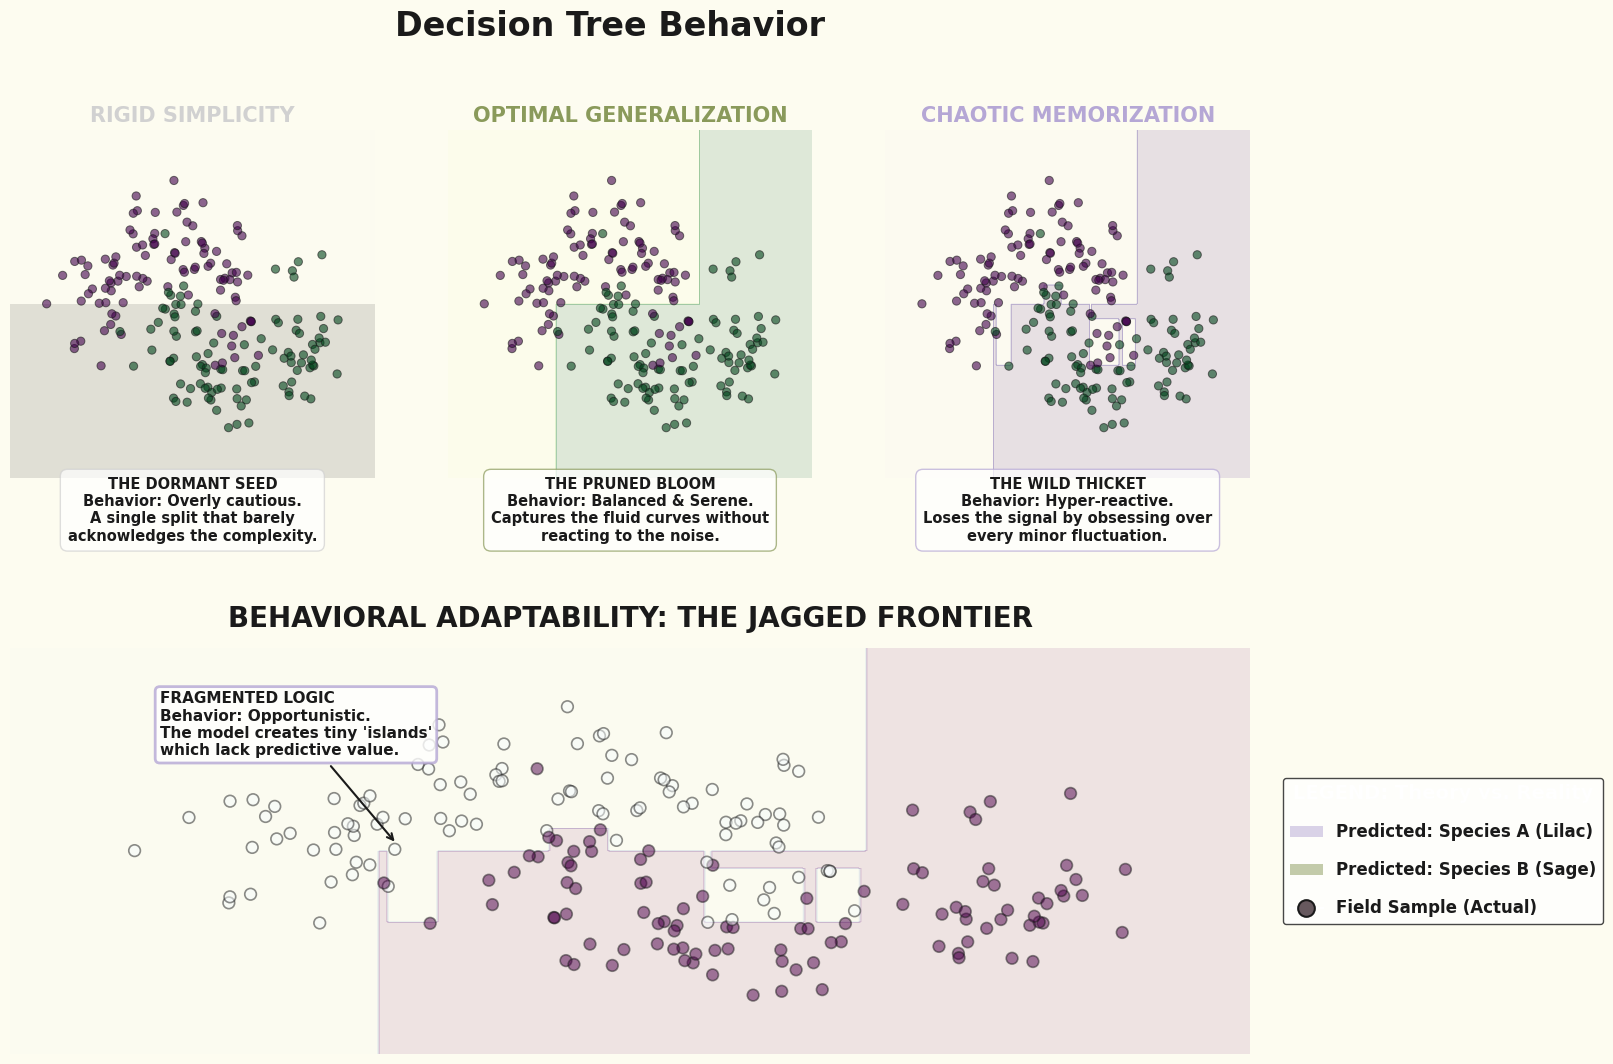

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from matplotlib import gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# --- 1. THE "ZEN" SPRING PALETTE ---
PARCHMENT = "#FDFCF0"
DUSKY_SAGE = "#8A9A5B"
FADED_LILAC = "#B5A7D5"
TEXT_BLACK = "#1A1A1A"
MIST_BLUE = "#9DBAD5"

# --- 2. DATA PREPARATION ---
X_vis, y_vis = make_moons(n_samples=200, noise=0.25, random_state=42)

configs = [
    {"depth": 1, "title": "RIGID SIMPLICITY", "accent": "#D1D1D1", "color": "Greys",
     "desc": "THE DORMANT SEED\nBehavior: Overly cautious.\nA single split that barely\nacknowledges the complexity."},
    {"depth": 4, "title": "OPTIMAL GENERALIZATION", "accent": DUSKY_SAGE, "color": "YlGn",
     "desc": "THE PRUNED BLOOM\nBehavior: Balanced & Serene.\nCaptures the fluid curves without\nreacting to the noise."},
    {"depth": None, "title": "CHAOTIC MEMORIZATION", "accent": FADED_LILAC, "color": "Purples",
     "desc": "THE WILD THICKET\nBehavior: Hyper-reactive.\nLoses the signal by obsessing over\nevery minor fluctuation."}
]

# --- 3. VISUALIZATION (Unified on Parchment) ---
fig = plt.figure(figsize=(16, 12), facecolor=PARCHMENT)
gs = gridspec.GridSpec(2, 3, height_ratios=[1.2, 1.4], hspace=0.45)
axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
ax_large = fig.add_subplot(gs[1, :])

# Meshgrid Setup
x_min, x_max = X_vis[:, 0].min() - 0.5, X_vis[:, 0].max() + 0.5
y_min, y_max = X_vis[:, 1].min() - 0.5, X_vis[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))

for i, config in enumerate(configs):
    axes[i].set_facecolor(PARCHMENT)
    model = DecisionTreeClassifier(max_depth=config["depth"], random_state=42).fit(X_vis, y_vis)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    axes[i].contourf(xx, yy, Z, alpha=0.12, cmap=config["color"])
    axes[i].scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap='PRGn',
                    edgecolors=TEXT_BLACK, s=35, alpha=0.6, linewidth=0.7, zorder=3)

    axes[i].set_title(config["title"], color=config["accent"], fontsize=15, fontweight='bold')
    axes[i].set_xticks([]); axes[i].set_yticks([])
    for spine in axes[i].spines.values():
        spine.set_visible(False)

    axes[i].text(0.5, -0.18, config["desc"], transform=axes[i].transAxes, ha='center',
                 fontsize=10.5, fontweight='bold', color=TEXT_BLACK,
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor=config["accent"], boxstyle="round,pad=0.5"))

# --- 4. THE JAGGED FRONTIER ---
overfit_model = DecisionTreeClassifier(random_state=42).fit(X_vis, y_vis)
Z_deep = overfit_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

ax_large.set_facecolor(PARCHMENT)
ax_large.contourf(xx, yy, Z_deep, alpha=0.1, cmap='BuPu')
ax_large.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap='BuPu',
                 edgecolors=TEXT_BLACK, s=70, zorder=3, alpha=0.5, linewidth=1.2)

ax_large.annotate("FRAGMENTED LOGIC\nBehavior: Opportunistic.\nThe model creates tiny 'islands'\nwhich lack predictive value.",
                  xy=(-0.55, 0.45), xytext=(-1.5, 1.2),
                  arrowprops=dict(arrowstyle="->", color=TEXT_BLACK, lw=1.5),
                  bbox=dict(boxstyle="round", fc="white", ec=FADED_LILAC, alpha=0.8, lw=2),
                  fontweight='bold', fontsize=11, color=TEXT_BLACK)

# --- 5. LEGEND (Enhanced Legibility) ---
legend_elements = [
    Patch(facecolor=FADED_LILAC, alpha=0.5, label='Predicted: Species A (Lilac)'),
    Patch(facecolor=DUSKY_SAGE, alpha=0.5, label='Predicted: Species B (Sage)'),
    Line2D([0], [0], marker='o', color='w', label='Field Sample (Actual)',
           markerfacecolor='#67595E', markersize=12, markeredgecolor=TEXT_BLACK, mew=1.5)
]

# Increase fontsize and title weight for maximum legibility
leg = ax_large.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5),
                      frameon=True, facecolor='white', edgecolor=TEXT_BLACK,
                      fontsize=12, labelspacing=1.2)

# Bold and enlarge the legend title
leg.set_title("LEGEND: Theory vs. Reality", prop={'size': 14, 'weight': 'bold'})

# Set all legend text to be bold for visibility
for text in leg.get_texts():
    text.set_fontweight('bold')
    text.set_color(TEXT_BLACK)

ax_large.set_title("BEHAVIORAL ADAPTABILITY: THE JAGGED FRONTIER", color=TEXT_BLACK, fontsize=20, fontweight='black', pad=15)
ax_large.set_xticks([]); ax_large.set_yticks([])
for spine in ax_large.spines.values(): spine.set_visible(False)

fig.suptitle("Decision Tree Behavior",
             fontsize=24, fontweight='black', color=TEXT_BLACK, y=0.98)

plt.tight_layout(rect=[0, 0.05, 0.82, 0.95])
plt.show()

# Part 4:
The Random Forest Ensemble

**Concept:**

A Random Forest is an ensemble of many Decision Trees. It builds hundreds of trees, each trained on a random subset of the data and using a random subset of the features. To make a prediction, it gets a vote from every tree in the "forest" and chooses the class that gets the most votes.This process of averaging the votes of many diverse trees makes the Random Forest much more robust and less prone to overfitting than a single tree.

**Your Task:**

Train a `RandomForestClassifier` and compare its accuracy to the single tree.

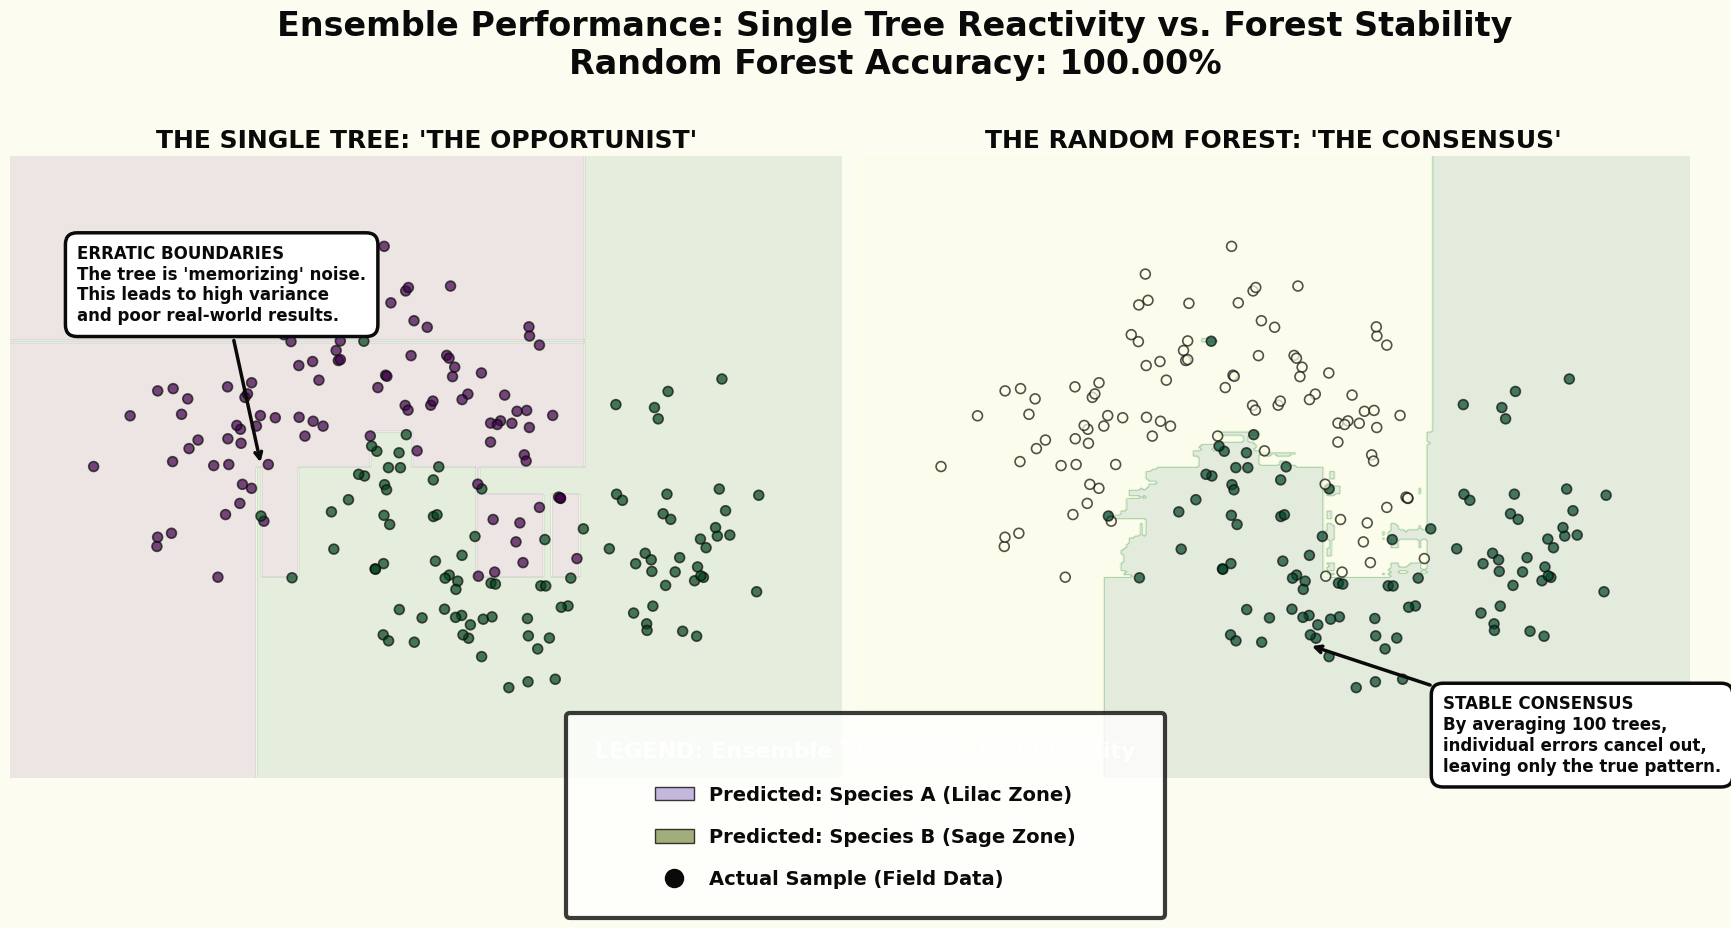

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# --- HIGH-CONTRAST "ZEN" PALETTE ---
CHARCOAL = "#0A0A0A"    # High-contrast charcoal for all text
PARCHMENT = "#FDFCF0"   # Unified soft cream background
LILAC_ZONE = "#B5A7D5"  # Faded Lilac for Species A
SAGE_ZONE = "#8A9A5B"   # Faded Sage for Species B

# --- 1. PLOT SETUP ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9), facecolor=PARCHMENT)

# Meshgrid for decision boundaries
xx, yy = np.meshgrid(np.linspace(X_vis[:, 0].min()-0.5, X_vis[:, 0].max()+0.5, 300),
                     np.linspace(X_vis[:, 1].min()-0.5, X_vis[:, 1].max()+0.5, 300))

# --- ANNOTATION STYLE (Solid White Box, Heavy Charcoal Text) ---
annot_style = dict(color=CHARCOAL, fontsize=12, fontweight='black',
                   bbox=dict(boxstyle="round,pad=0.7", fc='#FFFFFF',
                             ec=CHARCOAL, alpha=1.0, lw=2.5))

# --- 2. LEFT: THE SINGLE TREE (The Opportunist) ---
dt_model = DecisionTreeClassifier(random_state=42).fit(X_vis, y_vis)
Z1 = dt_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

ax1.set_facecolor(PARCHMENT)
# Decision boundaries set to ultra-faint alpha=0.1
ax1.contourf(xx, yy, Z1, alpha=0.1, cmap='PRGn')
ax1.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap='PRGn',
            edgecolors=CHARCOAL, s=50, alpha=0.7, linewidth=1.2)

ax1.set_title("THE SINGLE TREE: 'THE OPPORTUNIST'", fontsize=18, fontweight='black', color=CHARCOAL)
ax1.annotate("ERRATIC BOUNDARIES\nThe tree is 'memorizing' noise.\nThis leads to high variance\nand poor real-world results.",
             xy=(-0.6, 0.4), xytext=(-1.7, 1.2),
             arrowprops=dict(arrowstyle="->", color=CHARCOAL, lw=2.5),
             **annot_style)

# --- 3. RIGHT: THE RANDOM FOREST (The Consensus) ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_vis, y_vis)
Z2 = rf_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

ax2.set_facecolor(PARCHMENT)
ax2.contourf(xx, yy, Z2, alpha=0.1, cmap='YlGn')
ax2.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap='YlGn',
            edgecolors=CHARCOAL, s=50, alpha=0.7, linewidth=1.2)

ax2.set_title("THE RANDOM FOREST: 'THE CONSENSUS'", fontsize=18, fontweight='black', color=CHARCOAL)
ax2.annotate("STABLE CONSENSUS\nBy averaging 100 trees,\nindividual errors cancel out,\nleaving only the true pattern.",
             xy=(0.6, -0.6), xytext=(1.4, -1.3),
             arrowprops=dict(arrowstyle="->", color=CHARCOAL, lw=2.5),
             **annot_style)

# --- 4. THE NON-WASHED-OUT LEGEND ---
# Using high-alpha (solid) colors in the legend to contrast with faint plots
legend_elements = [
    Patch(facecolor=LILAC_ZONE, alpha=0.8, edgecolor=CHARCOAL, label='Predicted: Species A (Lilac Zone)'),
    Patch(facecolor=SAGE_ZONE, alpha=0.8, edgecolor=CHARCOAL, label='Predicted: Species B (Sage Zone)'),
    Line2D([0], [0], marker='o', color='w', label='Actual Sample (Field Data)',
           markerfacecolor=CHARCOAL, markersize=12, markeredgecolor=CHARCOAL, mew=2)
]

# Formatting axes
for ax in [ax1, ax2]:
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)

# Legend Configuration: Massive font, solid white box, heavy charcoal text
leg = fig.legend(handles=legend_elements, loc='lower center', ncol=1, frameon=True,
                 facecolor='#FFFFFF', edgecolor=CHARCOAL, fontsize=14, borderpad=1.5, labelspacing=1.2)

leg.get_frame().set_linewidth(3.0) # Thick border for the legend box
leg.set_title("LEGEND: Ensemble Theory vs. Field Reality", prop={'size': 16, 'weight': 'black'})

# Force all legend text to be ultra-bold charcoal
for text in leg.get_texts():
    text.set_fontweight('black')
    text.set_color(CHARCOAL)

# Main Title
plt.suptitle(f"Ensemble Performance: Single Tree Reactivity vs. Forest Stability\nRandom Forest Accuracy: {rf_acc:.2%}",
             fontsize=24, fontweight='black', color=CHARCOAL, y=1.02)

plt.tight_layout(rect=[0, 0.15, 1, 1]) # Extra room at bottom for the heavy legend
plt.show()

/tmp/ipykernel_5531/73948912.py:119: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.12, 1, 0.95])
/tmp/ipykernel_5531/73948912.py:119: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.12, 1, 0.95])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


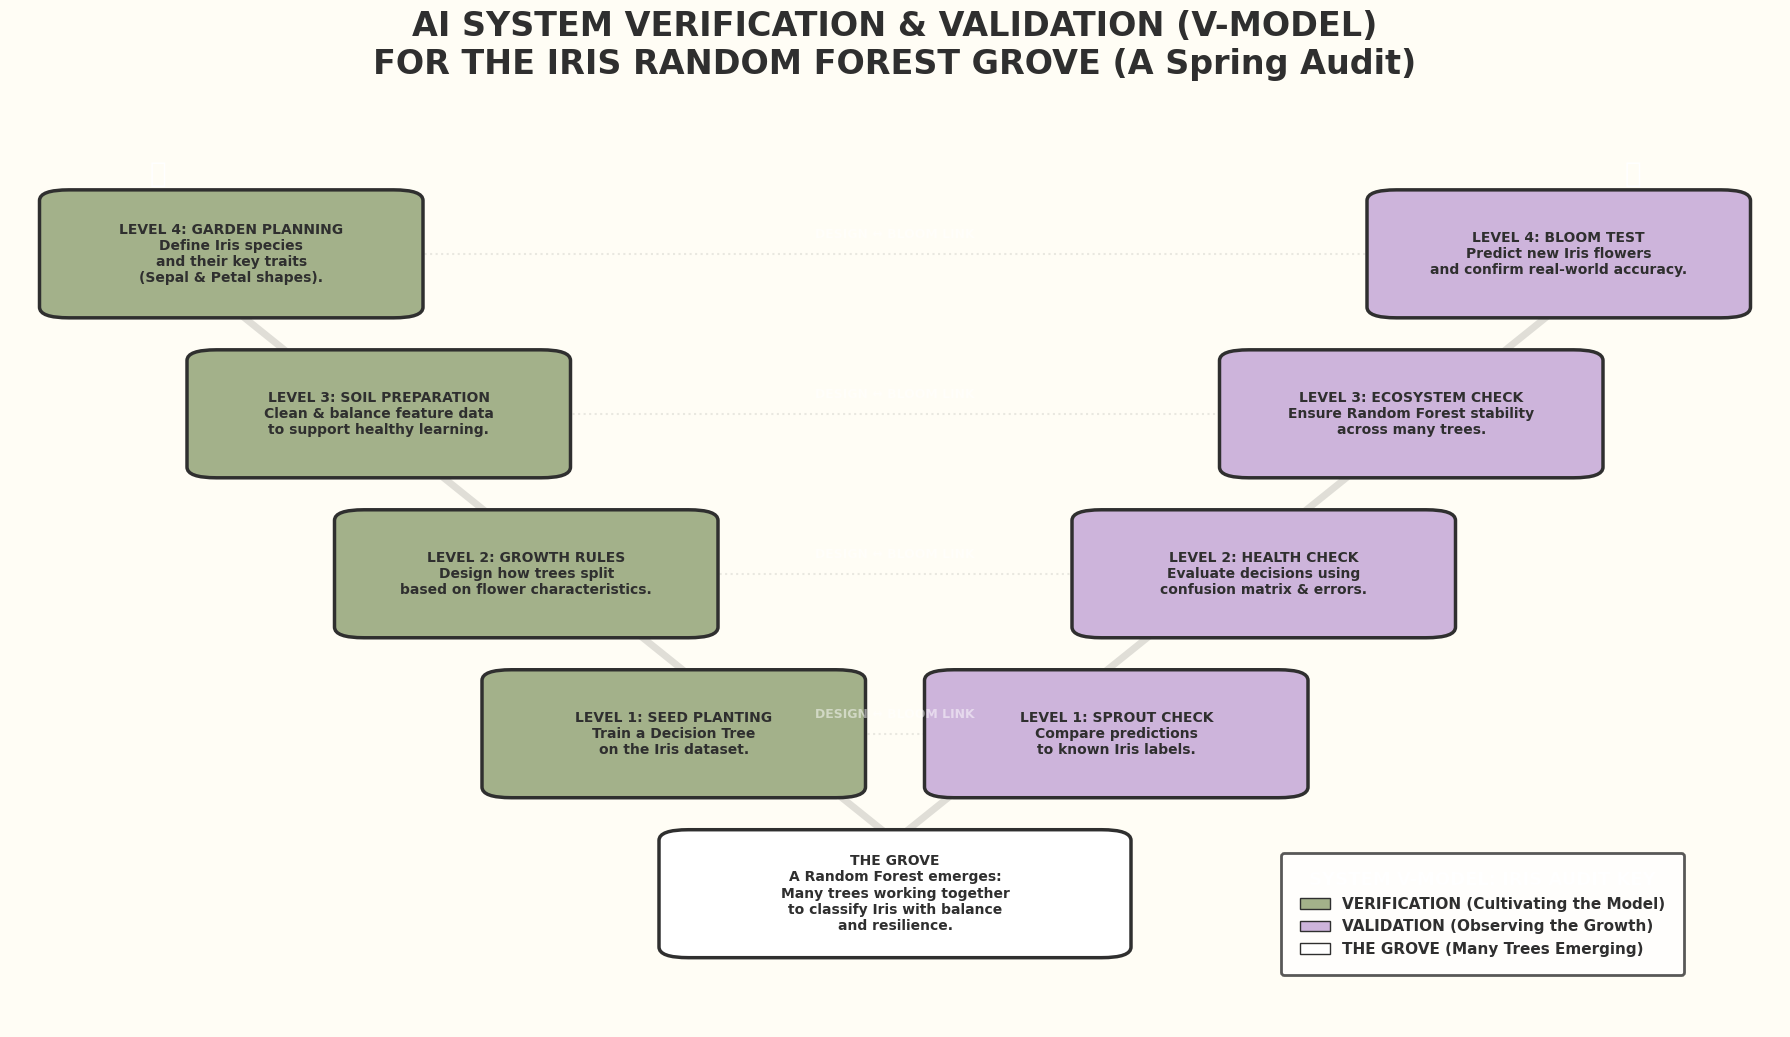

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
from sklearn.datasets import load_iris

# --- SPRING V-MODEL: BOTANICAL THEME ---

# 🎨 REVISED SPRING PALETTE (Soft but Clear)
# Swapping previous dusky sage for fresh green, lilac for pastel lavender
PARCHMENT = "#FFFDF5"     # Soft warm background
CHARCOAL = "#2F2F2F"      # Max legibility for text & borders

GARDEN_GREEN = "#A3B18A"  # Soft green (cultivation / design)
LILAC_ZONE = "#CDB4DB"    # Pastel lavender (validation)
WHITE = "#FFFFFF"

fig, ax = plt.subplots(figsize=(18, 12), facecolor=PARCHMENT)
ax.set_facecolor(PARCHMENT)

# Wide margins (0 to 12) for massive Level 1 clearance
ax.set_xlim(0, 12); ax.set_ylim(-2.5, 14)
ax.axis('off')

# --- 1. ENHANCED V-LOGIC (Botanical Metaphor) ---

# 🌱 LEFT: VERIFICATION (Cultivating the Model)
# Replaced technical specs with garden planning/planting logic
v_left = [
    (1.5, 12, "LEVEL 4: GARDEN PLANNING\nDefine Iris species\nand their key traits\n(Sepal & Petal shapes)."),

    (2.5, 9,  "LEVEL 3: SOIL PREPARATION\nClean & balance feature data\nto support healthy learning."),

    (3.5, 6,  "LEVEL 2: GROWTH RULES\nDesign how trees split\nbased on flower characteristics."),

    (4.5, 3,  "LEVEL 1: SEED PLANTING\nTrain a Decision Tree\non the Iris dataset.")
]

# 🌸 RIGHT: VALIDATION (Observing the Growth)
# Replaced technical audits with ecosystem/health checks
v_right = [
    (7.5, 3,  "LEVEL 1: SPROUT CHECK\nCompare predictions\nto known Iris labels."),

    (8.5, 6,  "LEVEL 2: HEALTH CHECK\nEvaluate decisions using\nconfusion matrix & errors."),

    (9.5, 9,  "LEVEL 3: ECOSYSTEM CHECK\nEnsure Random Forest stability\nacross many trees."),

    (10.5, 12, "LEVEL 4: BLOOM TEST\nPredict new Iris flowers\nand confirm real-world accuracy.")
]

# 🌳 BASE: WHERE IT ALL COMES TOGETHER
# Replaced "Construction Base" with "The Grove"
apex_box = (
    6, 0,
    "THE GROVE\nA Random Forest emerges:\nMany trees working together\nto classify Iris with balance\nand resilience."
)

# --- 2. RENDERING THE INFOGRAPHIC BLOCKS ---
def draw_block(x, y, text, color, text_color=CHARCOAL, is_apex=False):
    # Adjust width for the Base, keep standard for Levels
    width = 2.8 if is_apex else 2.2
    box = FancyBboxPatch((x-(width/2), y-1.0), width, 2.0, boxstyle="round,pad=0.2",
                         fc=color, ec=CHARCOAL, lw=2.5, alpha=1.0, zorder=3)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=10,
            fontweight='black', color=text_color)

# Draw Left Side (Cultivation - Green)
for x, y, txt in v_left: draw_block(x, y, txt, GARDEN_GREEN)

# Draw Right Side (Observation - Lavender)
for x, y, txt in v_right: draw_block(x, y, txt, LILAC_ZONE)

# Draw Base (The Grove - White/Reinforced)
draw_block(apex_box[0], apex_box[1], apex_box[2], WHITE, is_apex=True)

# --- 3. THE V-FRAMEWORK & THEMATIC TRACEABILITY ---
# The main V-path lines (Wide stance for clearance)
ax.add_line(Line2D([1.5, 6, 10.5], [11.0, 1.0, 11.0], color=CHARCOAL, lw=5, alpha=0.15, zorder=1))

# Horizontal Traceability Links (PLANNING vs. PROVING)
# 🔗 Replaced technical label with "DESIGN ↔ BLOOM LINK"
for y_val in [3, 6, 9, 12]:
    # Dynamic calculation for the wider V taper
    x_start = 4.5 if y_val == 3 else 3.5 if y_val == 6 else 2.5 if y_val == 9 else 1.5
    x_end = 12 - x_start
    ax.add_line(Line2D([x_start+1.2, x_end-1.2], [y_val, y_val], color=CHARCOAL, alpha=0.1, ls=':', zorder=1))

    # Trace Label: New thematic wording
    ax.text(6, y_val+0.3, "DESIGN ↔ BLOOM LINK", ha='center', fontsize=9, fontweight='bold', alpha=0.5)

# --- 4. THE SECURE SPRING LEGEND (No Overlap) ---
# Opaque white box to contrast with soft parchment background
legend_elements = [
    Patch(facecolor=GARDEN_GREEN, edgecolor=CHARCOAL, label='VERIFICATION (Cultivating the Model)'),
    Patch(facecolor=LILAC_ZONE, edgecolor=CHARCOAL, label='VALIDATION (Observing the Growth)'),
    Patch(facecolor=WHITE, edgecolor=CHARCOAL, label='THE GROVE (Many Trees Emerging)')
]

# Positioned far lower right to ensure the Construction Base isn't obstructed
leg = ax.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.95, 0.05),
                frameon=True, facecolor=WHITE, edgecolor=CHARCOAL, fontsize=11, borderpad=1.2)
leg.get_frame().set_linewidth(2.0)
leg.set_title("SYSTEM V-MODEL: IRIS AUDIT KEY", prop={'size': 13, 'weight': 'black'})

# Force all legend text to be ultra-bold Charcoal (not washed out)
for text in leg.get_texts():
    text.set_fontweight('black')
    text.set_color(CHARCOAL)

# Bold Main Title
plt.suptitle("AI SYSTEM VERIFICATION & VALIDATION (V-MODEL)\nFOR THE IRIS RANDOM FOREST GROVE (A Spring Audit)",
             fontsize=24, fontweight='black', color=CHARCOAL, y=0.98)

# Add small botanical accents to titles
ax.text(1, 13.5, "🌱", fontsize=20, ha='center', va='center', zorder=10)
ax.text(11, 13.5, "🌸", fontsize=20, ha='center', va='center', zorder=10)

plt.tight_layout(rect=[0, 0.12, 1, 0.95])
plt.show()

## Part 5:
#Feature Importance

**Concept:**

 A great benefit of tree-based ensembles like Random Forest is that they can tell you which features were most important for making accurate predictions.

 **Your Task:**

Extract and plot the feature importances from your trained Random Forest model.

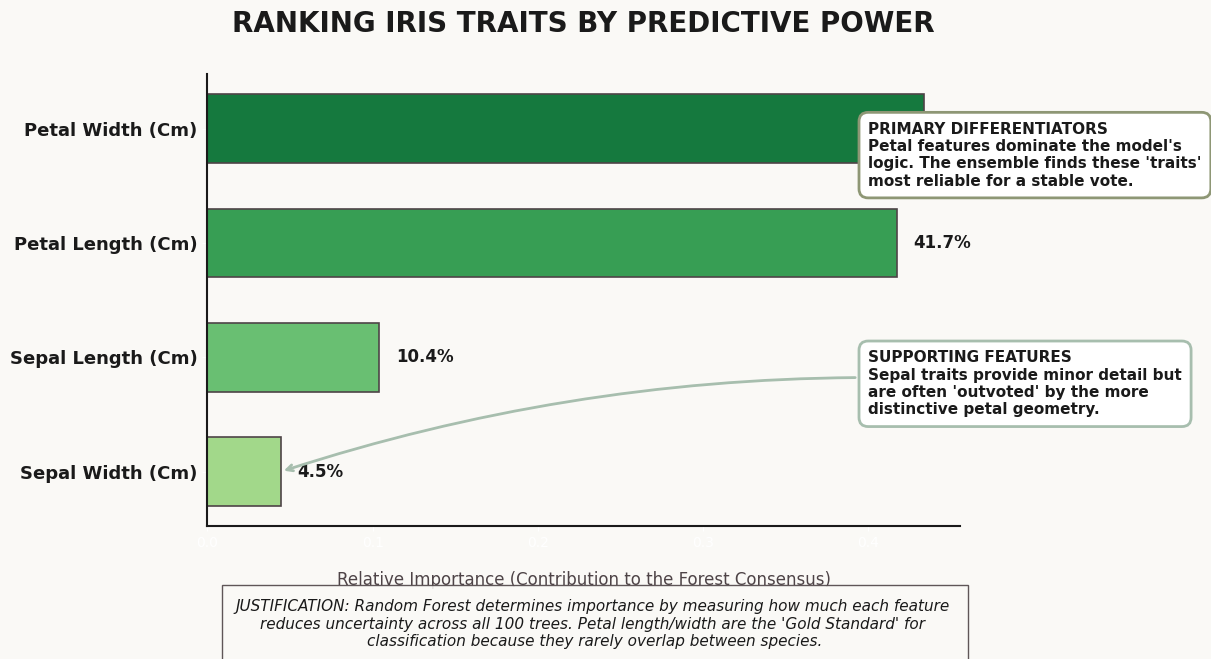

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Extract Feature Importance ---
# Assuming 'rf_model_full' was our trained ensemble from the previous block
importances = rf_model_full.feature_importances_
feature_names = iris.feature_names
indices = np.argsort(importances)

# --- 2. Design the "Spring Theme" Visualization ---
# Resetting to high-contrast legible light theme
CREAM_PAPER = "#FAF9F6"
EARTH_BROWN = "#4E4447"
TEXT_BLACK = "#1A1A1A"
MOSS_GREEN = "#8E9775"
MIST_TEAL = "#A7BEAE"

fig, ax = plt.subplots(figsize=(12, 7), facecolor=CREAM_PAPER)
ax.set_facecolor(CREAM_PAPER)

# Create a Spring Gradient (Misty Teal to Moss Green)
colors = plt.cm.YlGn(np.linspace(0.4, 0.8, len(indices)))

bars = ax.barh(range(len(indices)), importances[indices],
               color=colors, edgecolor=EARTH_BROWN, linewidth=1.2, height=0.6)

# --- 3. Aesthetics & High-Contrast Labeling ---
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feature_names[i].title() for i in indices],
                   fontsize=13, fontweight='bold', color=TEXT_BLACK)

ax.set_title("RANKING IRIS TRAITS BY PREDICTIVE POWER",
             fontsize=20, pad=30, color=TEXT_BLACK, fontweight='black')

ax.set_xlabel('Relative Importance (Contribution to the Forest Consensus)',
              fontsize=12, color=EARTH_BROWN, labelpad=15)

# Add bold percentage labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
            f'{width:.1%}', va='center', fontsize=12, color=TEXT_BLACK, fontweight='bold')

# Ensure axes/spines are visible
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color(TEXT_BLACK)
    ax.spines[spine].set_linewidth(1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- 4. MEANINGFUL ANNOTATIONS WITHIN THE VISUAL ---

# Annotation for Petal Traits (The Heavy Hitters)
ax.annotate("PRIMARY DIFFERENTIATORS\nPetal features dominate the model's\nlogic. The ensemble finds these 'traits'\nmost reliable for a stable vote.",
             xy=(importances[indices[-1]], len(indices)-1), xytext=(0.4, 2.5),
             fontsize=11, fontweight='bold', color=TEXT_BLACK,
             bbox=dict(boxstyle="round,pad=0.6", fc='white', ec=MOSS_GREEN, lw=2),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.1", color=MOSS_GREEN, lw=2))

# Annotation for Sepal Traits (The Supporting Details)
ax.annotate("SUPPORTING FEATURES\nSepal traits provide minor detail but\nare often 'outvoted' by the more\ndistinctive petal geometry.",
             xy=(importances[indices[0]], 0), xytext=(0.4, 0.5),
             fontsize=11, fontweight='bold', color=TEXT_BLACK,
             bbox=dict(boxstyle="round,pad=0.6", fc='white', ec=MIST_TEAL, lw=2),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.1", color=MIST_TEAL, lw=2))

# --- 5. Contextual Summary ---
description = (
    "JUSTIFICATION: Random Forest determines importance by measuring how much each feature \n"
    "reduces uncertainty across all 100 trees. Petal length/width are the 'Gold Standard' for \n"
    "classification because they rarely overlap between species."
)

plt.figtext(0.5, 0.02, description, ha='center', fontsize=11,
            color=TEXT_BLACK, style='italic', fontweight='medium',
            bbox=dict(facecolor=CREAM_PAPER, alpha=0.9, edgecolor=EARTH_BROWN, pad=10))

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

## 📝 Knowledge Check**Instructions:** Answer the following questions in this markdown cell.1.  **In your own words, what is the main idea behind ensemble methods? Why is a "committee" of models often better than a single expert model?**2.  **Which model performed better in this lab, the single Decision Tree or the Random Forest? Is this what you expected? Why?**3.  **Looking at the feature importance plot, which two features were most important for classifying the iris flowers?** Does this match what you might expect from your own knowledge of flowers?**[ENTER YOUR ANSWERS HERE]**